# Práctica: Modelado de Prestaciones (CBMG + Modelo de Colas + Escalado + Elasticidad)

Objetivo:
- Calcular tiempos de respuesta y utilizaciones de un sistema web (subastas).
- Estimar capacidad máxima (U≈0.90 y SLA=4s).
- Analizar el efecto de la mezcla de usuarios (fA).
- Estudiar escalado horizontal con penalización (Seidmann).
- Generar dataset experimental para elasticidad (aprendizaje de g(N,λ)).


In [38]:
# =========================
# 0) Setup del notebook
# =========================
# Librerías:
# - numpy: cálculo numérico
# - pandas: tablas
# - matplotlib: gráficas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1) Datos del problema (CBMG + Demandas)

Aquí definimos:
- Operaciones: h,s,v,g,c,b
- Visitas medias por sesión para A y B (Tabla 8.3)
- Mezcla base (fA=0.25) y mezcla alternativa (fA_alt=0.60)
- Demandas de servicio D(i,r) (Figura 3)


In [39]:
# Operaciones del sistema (clases del modelo)
ops = ["h", "s", "v", "g", "c", "b"]  # home, search, view, login, create, bid

# Visitas medias por sesión (Tabla 8.3)
V_A = {"h": 1.000, "s": 1.167, "v": 0.233, "g": 0.427, "c": 0.128, "b": 0.256}
V_B = {"h": 1.000, "s": 1.273, "v": 0.191, "g": 0.304, "c": 0.091, "b": 0.167}

# Mezclas (base y alternativa para comparar)
fA_base = 0.25
fA_alt  = 0.60

# Parámetros globales del estudio
SLA = 4.0
TARGET_U = 0.90
LAM_START = 5.0
LAM_STEP = 0.5


In [40]:
# Demandas (segundos) por recurso i y operación r (Figura 3)
D = pd.DataFrame(
    [
        #   h      s      v      g      c      b
        [0.008, 0.009, 0.011, 0.060, 0.012, 0.015],  # WS-CPU
        [0.030, 0.010, 0.010, 0.010, 0.010, 0.010],  # WS-disk
        [0.000, 0.030, 0.035, 0.025, 0.045, 0.040],  # AS-CPU
        [0.000, 0.008, 0.080, 0.009, 0.011, 0.012],  # AS-disk
        [0.000, 0.010, 0.009, 0.015, 0.070, 0.045],  # DS-CPU
        [0.000, 0.035, 0.018, 0.050, 0.080, 0.090],  # DS-disk
    ],
    index=["WS-CPU", "WS-disk", "AS-CPU", "AS-disk", "DS-CPU", "DS-disk"],
    columns=ops
)

D


,h,s,v,g,c,b
WS-CPU,0.008,0.009,0.011,0.060,0.012,0.015
WS-disk,0.030,0.010,0.010,0.010,0.010,0.010
AS-CPU,0.000,0.030,0.035,0.025,0.045,0.040
AS-disk,0.000,0.008,0.080,0.009,0.011,0.012
DS-CPU,0.000,0.010,0.009,0.015,0.070,0.045
DS-disk,0.000,0.035,0.018,0.050,0.080,0.090


## 2) Funciones auxiliares

- mixed_visits(fA): combina visitas medias de A y B.
- add_bottleneck_checks(df): recalcula U_max y bottleneck (sin errores).
- capacity_report(df): saca λ máximo por U≈0.90 y por SLA.


In [41]:
def mixed_visits(fA: float):
    """Visitas medias por operación para mezcla fA (y fB=1-fA)."""
    fB = 1 - fA
    return {r: fA * V_A[r] + fB * V_B[r] for r in ops}

def add_bottleneck_checks(df_in: pd.DataFrame) -> pd.DataFrame:
    """Añade U_max_check y bottleneck_check sin incluir U_max como recurso."""
    df = df_in.copy()
    U_cols = [c for c in df.columns if c.startswith("U_") and c != "U_max"]
    df["U_max_check"] = df[U_cols].max(axis=1)
    df["bottleneck_check"] = df[U_cols].idxmax(axis=1).str.replace("U_", "", regex=False)
    return df

def capacity_report(df_in: pd.DataFrame, target_U=TARGET_U, sla=SLA):
    """Devuelve resumen: capacidad por U y por SLA."""
    df = add_bottleneck_checks(df_in)

    hit  = df[df["U_max_check"] >= target_U].head(1)
    prev = df[df["U_max_check"] <  target_U].tail(1)

    lam_sla = df[df["T_total"] <= sla]["lambda"].max()

    return {
        "prev_row": prev[["lambda","U_max_check","bottleneck_check","T_total"]],
        "hit_row":  hit[["lambda","U_max_check","bottleneck_check","T_total"]],
        "lambda_sla": lam_sla
    }


## 3) Modelo de colas (sin penalización) — Configuración base (1,1,1)

Resuelve:
- Pregunta 1: T_r(λ) y U_i(λ) hasta U≈0.90
- Pregunta 2: T_total(λ) y SLA=4s


In [42]:
def compute_metrics(lam: float, fA: float, N_ws: int = 1, N_as: int = 1, N_ds: int = 1):
    """
    Modelo abierto sin penalización:
    - U_i = sum_r (λ_r/N_i)*D_{i,r}
    - T_{i,r} = D_{i,r}/(1-U_i)
    - T_r = sum_i T_{i,r}
    - T_total = sum_r T_r * (λ_r/λ)
    """
    mix = mixed_visits(fA)
    lambdas_r = pd.Series({r: lam * mix[r] for r in ops})

    N_map = {
        "WS-CPU": N_ws, "WS-disk": N_ws,
        "AS-CPU": N_as, "AS-disk": N_as,
        "DS-CPU": N_ds, "DS-disk": N_ds
    }

    # Utilización
    U = {}
    for i in D.index:
        Ni = N_map[i]
        U[i] = sum(lambdas_r[r] * D.loc[i, r] / Ni for r in ops)
    U = pd.Series(U)

    # T_{i,r}
    Tir = pd.DataFrame(index=D.index, columns=ops, dtype=float)
    for i in D.index:
        denom = 1.0 - U[i]
        if denom <= 0:
            Tir.loc[i, :] = np.inf
            continue
        for r in ops:
            Tir.loc[i, r] = 0.0 if D.loc[i, r] == 0 else D.loc[i, r] / denom

    Tr = Tir.sum(axis=0)
    T_total = float(sum(Tr[r] * (lambdas_r[r] / lam) for r in ops))

    return lambdas_r, U, Tr, T_total


In [43]:
def sweep_lambda(lam_start=LAM_START, step=LAM_STEP, target_U=TARGET_U, fA=fA_base,
                N_ws=1, N_as=1, N_ds=1, lam_cap=200):
    """Barrer λ hasta que U_max >= target_U y guardar tabla completa."""
    rows = []
    lam = lam_start

    while lam <= lam_cap:
        _, U, Tr, T_total = compute_metrics(lam, fA=fA, N_ws=N_ws, N_as=N_as, N_ds=N_ds)

        row = {
            "lambda": lam,
            "T_total": float(T_total),
            "U_max": float(U.max()),
            "bottleneck": U.idxmax(),
        }
        for r in ops:
            row[f"T_{r}"] = float(Tr[r])
        for i in U.index:
            row[f"U_{i}"] = float(U[i])

        rows.append(row)

        if U.max() >= target_U:
            break
        lam += step

    return pd.DataFrame(rows)


In [44]:
# ===== Configuración base (1,1,1) y mezcla base fA=0.25 =====
df_base = sweep_lambda(fA=fA_base, N_ws=1, N_as=1, N_ds=1)
rep_base = capacity_report(df_base)

print("== Capacidad por U≈0.90 (base) ==")
print("Primero que supera 0.90:")
print(rep_base["hit_row"])
print("\nÚltimo por debajo de 0.90:")
print(rep_base["prev_row"])

print("\n== Capacidad por SLA (T<=4s) ==")
print("lambda máximo por SLA:", rep_base["lambda_sla"])


== Capacidad por U≈0.90 (base) ==
Primero que supera 0.90:
    lambda  U_max_check bottleneck_check   T_total
11    10.5     0.934967          DS-disk  1.873011

Último por debajo de 0.90:
    lambda  U_max_check bottleneck_check   T_total
10    10.0     0.890445          DS-disk  1.285844

== Capacidad por SLA (T<=4s) ==
lambda máximo por SLA: 10.5


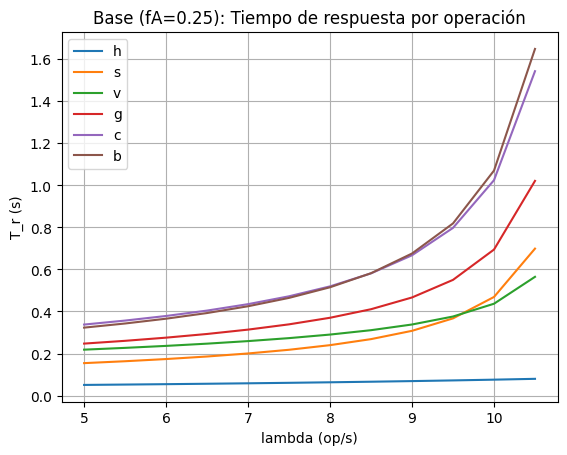

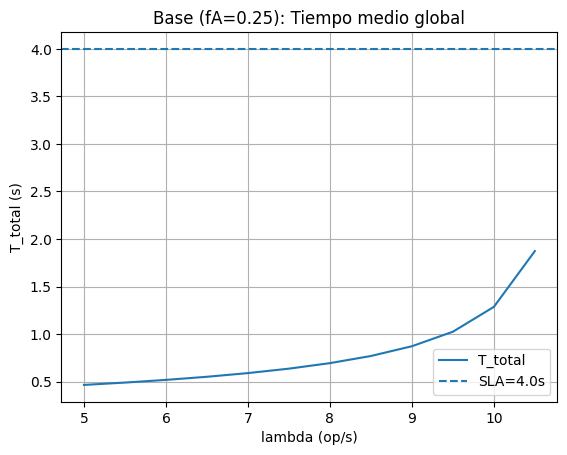

In [45]:
# Pregunta 1: T_r(λ)
plt.figure()
for r in ops:
    plt.plot(df_base["lambda"], df_base[f"T_{r}"], label=r)
plt.xlabel("lambda (op/s)")
plt.ylabel("T_r (s)")
plt.title("Base (fA=0.25): Tiempo de respuesta por operación")
plt.grid(True)
plt.legend()
plt.savefig("Tr_vs_lambda_base.png", dpi=200, bbox_inches="tight")
plt.show()

# Pregunta 2: T_total(λ) + SLA
plt.figure()
plt.plot(df_base["lambda"], df_base["T_total"], label="T_total")
plt.axhline(SLA, linestyle="--", label=f"SLA={SLA}s")
plt.xlabel("lambda (op/s)")
plt.ylabel("T_total (s)")
plt.title("Base (fA=0.25): Tiempo medio global")
plt.grid(True)
plt.legend()
plt.savefig("Ttotal_vs_lambda_base.png", dpi=200, bbox_inches="tight")
plt.show()


## 4) Pregunta 3: Repetir con otra mezcla y comparar

- Ejecutamos el barrido para fA=0.60
- Comparamos T_total(λ) entre fA=0.25 y fA=0.60


In [46]:
df_alt = sweep_lambda(fA=fA_alt, N_ws=1, N_as=1, N_ds=1)
rep_alt = capacity_report(df_alt)

print("== Capacidad por U≈0.90 (mezcla alternativa) ==")
print("Primero que supera 0.90:")
print(rep_alt["hit_row"])
print("\nÚltimo por debajo de 0.90:")
print(rep_alt["prev_row"])


== Capacidad por U≈0.90 (mezcla alternativa) ==
Primero que supera 0.90:
    lambda  U_max_check bottleneck_check   T_total
10    10.0     0.940026          DS-disk  2.084716

Último por debajo de 0.90:
   lambda  U_max_check bottleneck_check  T_total
9     9.5     0.893025          DS-disk  1.36437


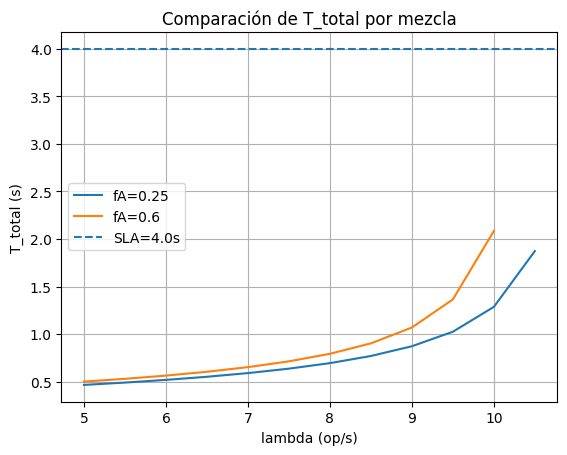

In [47]:
plt.figure()
plt.plot(df_base["lambda"], df_base["T_total"], label=f"fA={fA_base}")
plt.plot(df_alt["lambda"],  df_alt["T_total"],  label=f"fA={fA_alt}")
plt.axhline(SLA, linestyle="--", label=f"SLA={SLA}s")
plt.xlabel("lambda (op/s)")
plt.ylabel("T_total (s)")
plt.title("Comparación de T_total por mezcla")
plt.grid(True)
plt.legend()
plt.savefig("Ttotal_comparacion_mezclas.png", dpi=200, bbox_inches="tight")
plt.show()


## 5) Pregunta 4 y 5: λmax teórico y mejor mezcla

Idea:
- Como U_i(λ,fA) crece lineal con λ:
  U_i = λ * coef_i(fA)  =>  λmax_i = 0.90 / coef_i
- Capacidad del sistema: λmax = min_i λmax_i
- Luego graficamos λmax(fA) y buscamos la mezcla óptima.


In [48]:
def lambda_max_theoretical(fA: float, N_ws=1, N_as=1, N_ds=1, target_U=TARGET_U):
    mix = mixed_visits(fA)

    N_map = {
        "WS-CPU": N_ws, "WS-disk": N_ws,
        "AS-CPU": N_as, "AS-disk": N_as,
        "DS-CPU": N_ds, "DS-disk": N_ds
    }

    coef = {}
    for i in D.index:
        Ni = N_map[i]
        coef[i] = sum(mix[r] * D.loc[i, r] / Ni for r in ops)

    coef = pd.Series(coef)
    lam_max_i = target_U / coef
    bottleneck = lam_max_i.idxmin()
    lam_max = float(lam_max_i.min())

    return lam_max, bottleneck, lam_max_i


In [49]:
lam_th, bn_th, lam_by_res = lambda_max_theoretical(fA_base)

print("λmax teórico (fA=0.25):", lam_th)
print("Bottleneck teórico:", bn_th)
print("\nTop 3 recursos limitantes:")
print(lam_by_res.sort_values().head(3))


λmax teórico (fA=0.25): 10.107305897612992
Bottleneck teórico: DS-disk

Top 3 recursos limitantes:
DS-disk    10.107306
AS-CPU     13.868023
WS-disk    17.743605
dtype: float64


Mejor mezcla (máxima capacidad teórica):
fA                  0.0
lambda_max    10.525946
bottleneck      DS-disk
Name: 0, dtype: object


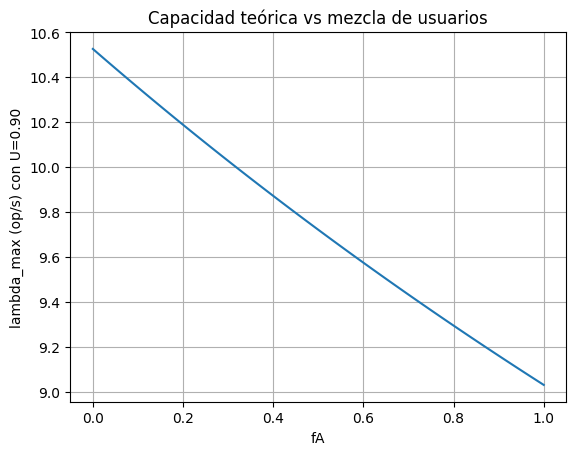

In [50]:
grid = np.linspace(0, 1, 101)
rows = []
for x in grid:
    lam_max, bn, _ = lambda_max_theoretical(float(x))
    rows.append({"fA": float(x), "lambda_max": lam_max, "bottleneck": bn})

df_lmax = pd.DataFrame(rows)
best = df_lmax.loc[df_lmax["lambda_max"].idxmax()]

print("Mejor mezcla (máxima capacidad teórica):")
print(best)

plt.figure()
plt.plot(df_lmax["fA"], df_lmax["lambda_max"])
plt.xlabel("fA")
plt.ylabel("lambda_max (op/s) con U=0.90")
plt.title("Capacidad teórica vs mezcla de usuarios")
plt.grid(True)
plt.savefig("lambda_max_vs_fA.png", dpi=200, bbox_inches="tight")
plt.show()


## 6) Escalado horizontal con penalización (Seidmann)

Ahora permitimos réplicas por capa (N_ws, N_as, N_ds) y usamos:
T_{i,r} = D_{i,r}*(Ni-1)/Ni + D_{i,r}/(1-U_i)

Objetivo:
- Probar configuraciones con límite N_ws+N_as+N_ds <= 16
- Para cada config: λmax (U=0.90) y T_total en λmax
- Construir tabla y comparar con base


In [51]:
fA_best = float(best["fA"])  # tu resultado óptimo (en tu caso 0.0)

def compute_metrics_seidmann(lam: float, fA: float, N_ws: int, N_as: int, N_ds: int):
    mix = mixed_visits(fA)
    lambdas_r = pd.Series({r: lam * mix[r] for r in ops})

    N_map = {
        "WS-CPU": N_ws, "WS-disk": N_ws,
        "AS-CPU": N_as, "AS-disk": N_as,
        "DS-CPU": N_ds, "DS-disk": N_ds
    }

    U = {}
    for i in D.index:
        Ni = N_map[i]
        U[i] = sum(lambdas_r[r] * D.loc[i, r] / Ni for r in ops)
    U = pd.Series(U)

    Tir = pd.DataFrame(index=D.index, columns=ops, dtype=float)
    for i in D.index:
        Ni = N_map[i]
        denom = 1.0 - U[i]
        for r in ops:
            Di_r = D.loc[i, r]
            if Di_r == 0:
                Tir.loc[i, r] = 0.0
            elif denom <= 0:
                Tir.loc[i, r] = np.inf
            else:
                penalty = Di_r * (Ni - 1) / Ni
                queueing = Di_r / denom
                Tir.loc[i, r] = penalty + queueing

    Tr = Tir.sum(axis=0)
    T_total = float(sum(Tr[r] * (lambdas_r[r] / lam) for r in ops))

    return lambdas_r, U, Tr, T_total


In [52]:
def lambda_max_theoretical_layer(fA: float, N_ws: int, N_as: int, N_ds: int, target_U=TARGET_U):
    mix = mixed_visits(fA)

    N_map = {
        "WS-CPU": N_ws, "WS-disk": N_ws,
        "AS-CPU": N_as, "AS-disk": N_as,
        "DS-CPU": N_ds, "DS-disk": N_ds
    }

    coef = {}
    for i in D.index:
        Ni = N_map[i]
        coef[i] = sum(mix[r] * D.loc[i, r] / Ni for r in ops)

    coef = pd.Series(coef)
    lam_max_i = target_U / coef
    bn = lam_max_i.idxmin()
    lam_max = float(lam_max_i.min())
    return lam_max, bn, lam_max_i

def eval_config(N_ws: int, N_as: int, N_ds: int, fA: float, target_U=TARGET_U):
    lam_max, bn, _ = lambda_max_theoretical_layer(fA, N_ws, N_as, N_ds, target_U=target_U)
    _, U, _, T_at = compute_metrics_seidmann(lam_max, fA=fA, N_ws=N_ws, N_as=N_as, N_ds=N_ds)
    return {
        "N_ws": N_ws, "N_as": N_as, "N_ds": N_ds,
        "N_total": N_ws + N_as + N_ds,
        "lambda_max": lam_max,
        "bottleneck": bn,
        "T_at_lambda_max": float(T_at),
        "U_max": float(U.max())
    }


In [53]:
Nmax_total = 16

rows = []
for N_ws in range(1, Nmax_total + 1):
    for N_as in range(1, Nmax_total + 1):
        for N_ds in range(1, Nmax_total + 1):
            if N_ws + N_as + N_ds <= Nmax_total:
                rows.append(eval_config(N_ws, N_as, N_ds, fA=fA_best))

summary = pd.DataFrame(rows)

# Top configs por capacidad y coste
summary.sort_values(["lambda_max", "N_total"], ascending=[False, True]).head(15)


,N_ws,N_as,N_ds,N_total,lambda_max,bottleneck,T_at_lambda_max,U_max
318,4,5,7,16,71.146245,AS-CPU,2.302320,0.9
317,4,5,6,15,63.155679,DS-disk,1.897154,0.9
324,4,6,6,16,63.155679,DS-disk,1.769952,0.9
379,5,5,6,16,63.155679,DS-disk,1.754227,0.9
309,4,4,6,14,56.916996,AS-CPU,1.718708,0.9
310,4,4,7,15,56.916996,AS-CPU,1.546537,0.9
372,5,4,6,15,56.916996,AS-CPU,1.636719,0.9
311,4,4,8,16,56.916996,AS-CPU,1.484445,0.9
373,5,4,7,16,56.916996,AS-CPU,1.464547,0.9
424,6,4,6,16,56.916996,AS-CPU,1.606433,0.9


In [54]:
base = eval_config(1, 1, 1, fA=fA_best)
print("Base (1,1,1) con Seidmann y fA_best:")
print(base)

summary["improvement_vs_base"] = summary["lambda_max"] / base["lambda_max"]
summary.sort_values(["improvement_vs_base", "N_total"], ascending=[False, True]).head(10)


Base (1,1,1) con Seidmann y fA_best:
{'N_ws': 1, 'N_as': 1, 'N_ds': 1, 'N_total': 3, 'lambda_max': 10.525946458019018, 'bottleneck': 'DS-disk', 'T_at_lambda_max': 1.3276524946887516, 'U_max': 0.9000000000000002}


,N_ws,N_as,N_ds,N_total,lambda_max,bottleneck,T_at_lambda_max,U_max,improvement_vs_base
318,4,5,7,16,71.146245,AS-CPU,2.302320,0.9,6.759130
317,4,5,6,15,63.155679,DS-disk,1.897154,0.9,6.000000
324,4,6,6,16,63.155679,DS-disk,1.769952,0.9,6.000000
379,5,5,6,16,63.155679,DS-disk,1.754227,0.9,6.000000
309,4,4,6,14,56.916996,AS-CPU,1.718708,0.9,5.407304
310,4,4,7,15,56.916996,AS-CPU,1.546537,0.9,5.407304
372,5,4,6,15,56.916996,AS-CPU,1.636719,0.9,5.407304
311,4,4,8,16,56.916996,AS-CPU,1.484445,0.9,5.407304
373,5,4,7,16,56.916996,AS-CPU,1.464547,0.9,5.407304
424,6,4,6,16,56.916996,AS-CPU,1.606433,0.9,5.407304


## 7) Elasticidad: construir dataset (N, λ) -> T_total

Creamos una base de datos de "experimentos" para simular que:
- NO conocemos el modelo real
- Solo tenemos mediciones de T_total para distintas configuraciones y cargas
Luego se usará para aprender g(N,λ) y diseñar un controlador (hill climbing).


In [55]:
def build_learning_db(configs_df, fA: float, points_per_config=8, target_U=TARGET_U):
    db = []
    gamma = 1

    for _, row in configs_df.iterrows():
        N_ws, N_as, N_ds = int(row["N_ws"]), int(row["N_as"]), int(row["N_ds"])
        lam_max, _, _ = lambda_max_theoretical_layer(fA, N_ws, N_as, N_ds, target_U=target_U)

        lam_values = np.linspace(LAM_START, lam_max, points_per_config)
        for lam in lam_values:
            _, U, _, T_total = compute_metrics_seidmann(float(lam), fA=fA, N_ws=N_ws, N_as=N_as, N_ds=N_ds)
            db.append({
                "gamma": gamma,
                "lambda": float(lam),
                "N_ws": N_ws, "N_as": N_as, "N_ds": N_ds,
                "N_total": N_ws + N_as + N_ds,
                "T_total": float(T_total),
                "U_max": float(U.max())
            })
            gamma += 1

    return pd.DataFrame(db)

# Muestra de configs para dataset (puedes subir/bajar n)
configs_sample = summary.sample(n=30, random_state=1)

learning_db = build_learning_db(configs_sample, fA=fA_best, points_per_config=8)

print("learning_db shape:", learning_db.shape)
learning_db.head()


learning_db shape: (240, 8)


,gamma,lambda,N_ws,N_as,N_ds,N_total,T_total,U_max
0,1,5.000000,5,3,3,11,0.553243,0.142505
1,2,8.796834,5,3,3,11,0.581461,0.250719
2,3,12.593668,5,3,3,11,0.616654,0.358932
3,4,16.390503,5,3,3,11,0.662421,0.467146
4,5,20.187337,5,3,3,11,0.725710,0.575359


In [56]:
learning_db.to_csv("learning_db.csv", index=False)
summary.to_csv("summary_configs.csv", index=False)

print("Guardados: learning_db.csv y summary_configs.csv")


Guardados: learning_db.csv y summary_configs.csv


## 8) Escalado horizontal (Seidmann): tabla final y conclusiones

Objetivo (parte de escalado del enunciado):
- Evaluar configuraciones (N_ws, N_as, N_ds) con límite N_total ≤ 16
- Para cada configuración:
  - λ_max por utilización (U≈0.90)
  - T_total en λ_max usando el modelo con penalización de Seidmann
- Construir una tabla final con las configuraciones más interesantes y compararlas con la base.


In [57]:
# Requisitos: debe existir `summary`, `base` y `Nmax_total` de la sección 6

# 1) Elegimos 1 configuración "mejor" por cada N_total (para tener variedad de coste)
best_by_cost = (
    summary.sort_values(["N_total", "lambda_max", "T_at_lambda_max"], ascending=[True, False, True])
           .groupby("N_total", as_index=False)
           .head(1)
)

# 2) Además, cogemos el TOP global por capacidad (por si no cae en best_by_cost)
top_global = summary.sort_values(["lambda_max", "N_total"], ascending=[False, True]).head(10)

# 3) Unimos y quitamos duplicados
final_configs = (
    pd.concat([best_by_cost, top_global], ignore_index=True)
      .drop_duplicates(subset=["N_ws","N_as","N_ds"])
)

# Orden final “bonito”: primero por coste y luego por capacidad
final_configs = final_configs.sort_values(["N_total","lambda_max"], ascending=[True, False])

final_configs.head(20)


,N_ws,N_as,N_ds,N_total,lambda_max,bottleneck,T_at_lambda_max,U_max,improvement_vs_base
0,1,1,1,3,10.525946,DS-disk,1.327652,0.9,1.000000
1,1,1,2,4,14.229249,AS-CPU,1.298964,0.9,1.351826
2,1,2,2,5,17.906884,WS-disk,1.404143,0.9,1.701214
3,2,2,2,6,21.051893,DS-disk,1.480906,0.9,2.000000
4,2,2,3,7,28.458498,AS-CPU,1.651948,0.9,2.703652
5,2,3,3,8,31.577839,DS-disk,1.711063,0.9,3.000000
6,2,3,4,9,35.813768,WS-disk,1.615140,0.9,3.402427
7,3,3,4,10,42.103786,DS-disk,2.019819,0.9,4.000000
8,3,3,5,11,42.687747,AS-CPU,1.561047,0.9,4.055478
9,3,4,5,12,52.629732,DS-disk,2.169962,0.9,5.000000


In [58]:
# Creamos columnas de comparación con base
final_table = final_configs.copy()
final_table["improvement_vs_base"] = final_table["lambda_max"] / base["lambda_max"]

# Reordenamos columnas para informe
cols = [
    "N_ws","N_as","N_ds","N_total",
    "lambda_max","T_at_lambda_max","U_max","bottleneck",
    "improvement_vs_base"
]
final_table = final_table[cols]

# Redondeo para que quede presentable
final_table_display = final_table.copy()
final_table_display["lambda_max"] = final_table_display["lambda_max"].round(3)
final_table_display["T_at_lambda_max"] = final_table_display["T_at_lambda_max"].round(3)
final_table_display["U_max"] = final_table_display["U_max"].round(3)
final_table_display["improvement_vs_base"] = final_table_display["improvement_vs_base"].round(2)

final_table_display.head(25)


,N_ws,N_as,N_ds,N_total,lambda_max,T_at_lambda_max,U_max,bottleneck,improvement_vs_base
0,1,1,1,3,10.526,1.328,0.9,DS-disk,1.00
1,1,1,2,4,14.229,1.299,0.9,AS-CPU,1.35
2,1,2,2,5,17.907,1.404,0.9,WS-disk,1.70
3,2,2,2,6,21.052,1.481,0.9,DS-disk,2.00
4,2,2,3,7,28.458,1.652,0.9,AS-CPU,2.70
5,2,3,3,8,31.578,1.711,0.9,DS-disk,3.00
6,2,3,4,9,35.814,1.615,0.9,WS-disk,3.40
7,3,3,4,10,42.104,2.020,0.9,DS-disk,4.00
8,3,3,5,11,42.688,1.561,0.9,AS-CPU,4.06
9,3,4,5,12,52.630,2.170,0.9,DS-disk,5.00


In [59]:
final_table_display.to_csv("tabla_escalado_final.csv", index=False)
print("Guardado: tabla_escalado_final.csv")


Guardado: tabla_escalado_final.csv


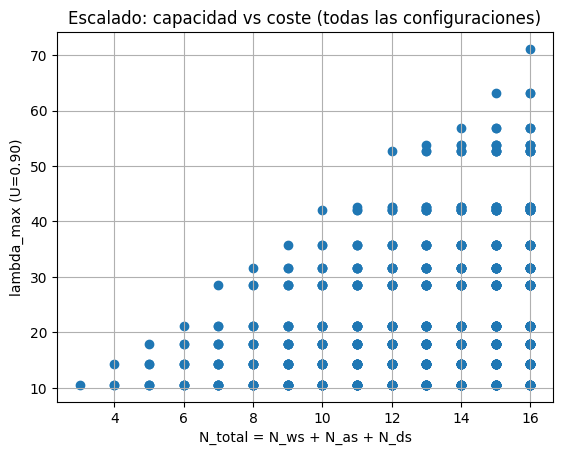

In [60]:
# Capacidad (lambda_max) vs coste (N_total)
plt.figure()
plt.scatter(summary["N_total"], summary["lambda_max"])
plt.xlabel("N_total = N_ws + N_as + N_ds")
plt.ylabel("lambda_max (U=0.90)")
plt.title("Escalado: capacidad vs coste (todas las configuraciones)")
plt.grid(True)
plt.savefig("capacidad_vs_coste.png", dpi=200, bbox_inches="tight")
plt.show()


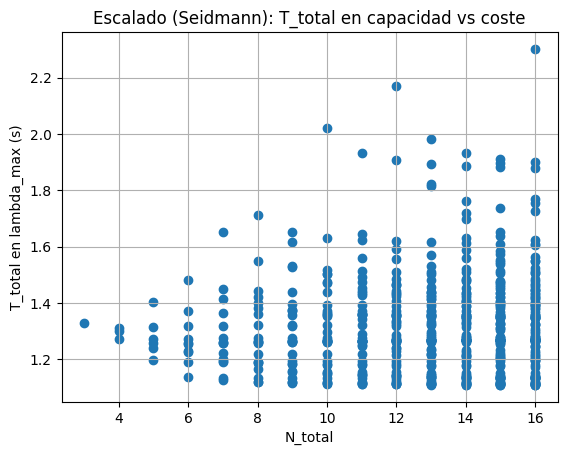

In [61]:
plt.figure()
plt.scatter(summary["N_total"], summary["T_at_lambda_max"])
plt.xlabel("N_total")
plt.ylabel("T_total en lambda_max (s)")
plt.title("Escalado (Seidmann): T_total en capacidad vs coste")
plt.grid(True)
plt.savefig("T_en_lmax_vs_coste.png", dpi=200, bbox_inches="tight")
plt.show()


## 9) Elasticidad (aprendizaje + control)

Objetivo (parte de elasticidad del enunciado):
- Suponemos que NO conocemos el modelo real.
- Solo tenemos una base de datos de mediciones (learning_db.csv) con:
  (N_ws, N_as, N_ds, λ) -> T_total
- Aprendemos una función aproximada g(N,λ) que predice T_total.
- Definimos una utilidad μ que mezcla:
  - rendimiento (carga atendida)
  - coste (nº de servidores)
  - penalización por violar SLA (T>4s)
- Diseñamos un controlador que elige N(t) (hill climbing) con una predicción de carga λ̂(t).
- Simulamos λ(t) y graficamos resultados.


In [65]:
# Si ya tienes `learning_db` en memoria, esta celda funciona igual.
# Si no, descomenta la lectura:
# learning_db = pd.read_csv("learning_db.csv")

def make_features(df: pd.DataFrame) -> np.ndarray:
    """
    Features sencillas para aproximar g(N,λ).
    Usamos términos lineales y algunos no lineales razonables:
    - 1
    - λ, λ^2
    - 1/N_ws, 1/N_as, 1/N_ds
    - λ/N_ws, λ/N_as, λ/N_ds
    """
    lam = df["lambda"].to_numpy()
    Nw = df["N_ws"].to_numpy()
    Na = df["N_as"].to_numpy()
    Nd = df["N_ds"].to_numpy()

    X = np.column_stack([
        np.ones_like(lam),
        lam,
        lam**2,
        1.0/Nw, 1.0/Na, 1.0/Nd,
        lam/Nw, lam/Na, lam/Nd
    ])
    return X

def fit_g_logT(learning_df: pd.DataFrame):
    """
    Ajusta un modelo lineal sobre log(T_total) para garantizar T_pred > 0.
    log(T) = Xβ  =>  T_pred = exp(Xβ)
    """
    df = learning_df.copy()
    # evitamos problemas si hubiese T=0 (no debería)
    df["T_total"] = df["T_total"].clip(lower=1e-9)

    X = make_features(df)
    y = np.log(df["T_total"].to_numpy())

    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return beta

def predict_g(beta: np.ndarray, N_ws: int, N_as: int, N_ds: int, lam: float) -> float:
    tmp = pd.DataFrame([{
        "lambda": lam,
        "N_ws": N_ws, "N_as": N_as, "N_ds": N_ds
    }])
    X = make_features(tmp)

    # X@beta devuelve un array (1,), extraemos el escalar correctamente:
    logT = (X @ beta).item()
    return float(np.exp(logT))

beta = fit_g_logT(learning_db)
print("Modelo g entrenado (beta shape):", beta.shape)


Modelo g entrenado (beta shape): (9,)


In [66]:
# Validación rápida con error medio absoluto en la misma muestra (simple, no es CV).
preds = []
for _, row in learning_db.sample(n=min(300, len(learning_db)), random_state=0).iterrows():
    preds.append(predict_g(beta, int(row["N_ws"]), int(row["N_as"]), int(row["N_ds"]), float(row["lambda"])))

sample = learning_db.sample(n=min(300, len(learning_db)), random_state=0).copy()
sample["T_pred"] = preds
mae = np.mean(np.abs(sample["T_pred"] - sample["T_total"]))
mape = np.mean(np.abs(sample["T_pred"] - sample["T_total"]) / sample["T_total"]) * 100

print(f"MAE aprox: {mae:.3f} s")
print(f"MAPE aprox: {mape:.1f} %")


MAE aprox: 0.069 s
MAPE aprox: 7.6 %


In [67]:
# Pesos de la utilidad (puedes ajustarlos si quieres)
W_TH   = 1.0   # peso del throughput (λ)
W_COST = 0.08  # peso del coste (N_total)
W_SLA  = 2.0   # penalización por violar SLA

def utility(lam: float, T: float, N_total: int, sla=SLA,
            w_th=W_TH, w_cost=W_COST, w_sla=W_SLA) -> float:
    """
    Utilidad μ:
    + w_th * λ
    - w_cost * N_total
    - w_sla * penalización si T > SLA
    """
    sla_penalty = max(0.0, (T - sla) / sla)
    return w_th * lam - w_cost * N_total - w_sla * sla_penalty


In [68]:
# Precomputamos todas las configuraciones factibles con N_total <= 16
def all_configs(Nmax_total=16):
    cfgs = []
    for N_ws in range(1, Nmax_total+1):
        for N_as in range(1, Nmax_total+1):
            for N_ds in range(1, Nmax_total+1):
                if N_ws + N_as + N_ds <= Nmax_total:
                    cfgs.append((N_ws, N_as, N_ds))
    return cfgs

CFG_LIST = all_configs(Nmax_total)

def neighbors(cfg, Nmax_total=16):
    """
    Vecinos: sumar/restar 1 a una capa, manteniendo Ni>=1 y N_total<=Nmax_total
    """
    N_ws, N_as, N_ds = cfg
    cand = [
        (N_ws+1, N_as,   N_ds),
        (N_ws-1, N_as,   N_ds),
        (N_ws,   N_as+1, N_ds),
        (N_ws,   N_as-1, N_ds),
        (N_ws,   N_as,   N_ds+1),
        (N_ws,   N_as,   N_ds-1),
    ]
    out = []
    for a,b,c in cand:
        if a >= 1 and b >= 1 and c >= 1 and (a+b+c) <= Nmax_total:
            out.append((a,b,c))
    return out


In [70]:
def choose_config_learned(lam_hat: float, start_cfg=(1,1,1), Nmax_total=16):
    """
    Hill climbing usando T_pred = g(N, lam_hat).
    Añadimos una restricción suave: si lam_hat > lambda_max_teorico(N) => penalizamos mucho.
    """
    cfg = start_cfg

    def score(cfg):
        N_ws, N_as, N_ds = cfg
        # Guard: si la carga supera la capacidad por U=0.9, lo hacemos muy malo
        lam_cap, _, _ = lambda_max_theoretical_layer(fA_best, N_ws, N_as, N_ds, target_U=TARGET_U)
        if lam_hat > lam_cap:
            return -1e9

        T_pred = predict_g(beta, N_ws, N_as, N_ds, lam_hat)
        return utility(lam_hat, T_pred, N_ws+N_as+N_ds)

    improved = True
    while improved:
        improved = False
        best_cfg = cfg
        best_score = score(cfg)

        for nb in neighbors(cfg, Nmax_total):
            sc = score(nb)
            if sc > best_score:
                best_score = sc
                best_cfg = nb
                improved = True

        cfg = best_cfg

    return cfg


## 10) Simulación temporal λ(t)

- Generamos una trayectoria de carga λ(t) con patrón suave + picos.
- Usamos una predicción simple λ̂(t) (naive: λ̂(t)=λ(t-1)).
- Ejecutamos el controlador aprendido y medimos el rendimiento REAL usando el modelo Seidmann.
- Graficamos: λ(t), N_total(t), T_total(t) y μ(t).


In [71]:
T_STEPS = 200

# Carga sintética: base + onda + picos
t = np.arange(T_STEPS)
lam_true = 6.0 + 2.0*np.sin(2*np.pi*t/50)  # patrón suave
lam_true = lam_true + (t % 60 == 0)*3.0    # pico cada 60
lam_true = np.clip(lam_true, 1.0, None)

# Predicción naive: usa el valor anterior (en t=0 usa el real)
lam_hat = np.zeros_like(lam_true)
lam_hat[0] = lam_true[0]
lam_hat[1:] = lam_true[:-1]


In [72]:
cfg_hist = []
Ntot_hist = []
T_real_hist = []
mu_real_hist = []

cfg = (1,1,1)

for k in range(T_STEPS):
    # 1) elegimos config usando predicción
    cfg = choose_config_learned(float(lam_hat[k]), start_cfg=cfg, Nmax_total=Nmax_total)
    N_ws, N_as, N_ds = cfg

    # 2) medimos tiempo REAL con el modelo de Seidmann (modelo “verdadero”)
    _, U_real, _, T_real = compute_metrics_seidmann(float(lam_true[k]), fA=fA_best, N_ws=N_ws, N_as=N_as, N_ds=N_ds)
    N_total = N_ws + N_as + N_ds
    mu = utility(float(lam_true[k]), float(T_real), N_total)

    cfg_hist.append(cfg)
    Ntot_hist.append(N_total)
    T_real_hist.append(float(T_real))
    mu_real_hist.append(float(mu))

# DataFrame con resultados
sim_learned = pd.DataFrame({
    "t": t,
    "lambda_true": lam_true,
    "lambda_hat": lam_hat,
    "N_ws": [c[0] for c in cfg_hist],
    "N_as": [c[1] for c in cfg_hist],
    "N_ds": [c[2] for c in cfg_hist],
    "N_total": Ntot_hist,
    "T_real": T_real_hist,
    "mu_real": mu_real_hist
})

sim_learned.head()


,t,lambda_true,lambda_hat,N_ws,N_as,N_ds,N_total,T_real,mu_real
0,0,9.000000,9.000000,1,1,1,3,0.770921,8.760000
1,1,6.250666,9.000000,1,1,1,3,0.501271,6.010666
2,2,6.497380,6.250666,1,1,1,3,0.515798,6.257380
3,3,6.736249,6.497380,1,1,1,3,0.530922,6.496249
4,4,6.963507,6.736249,1,1,1,3,0.546407,6.723507


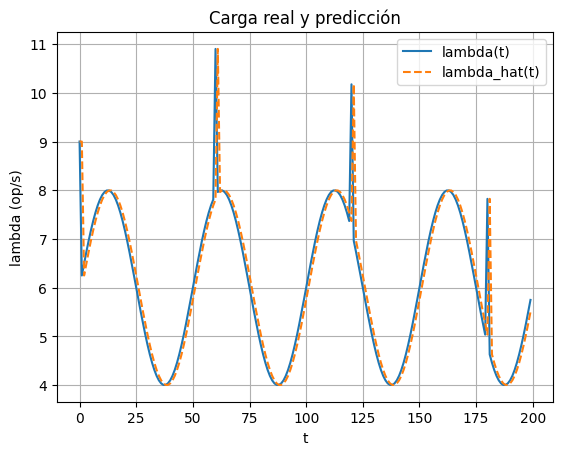

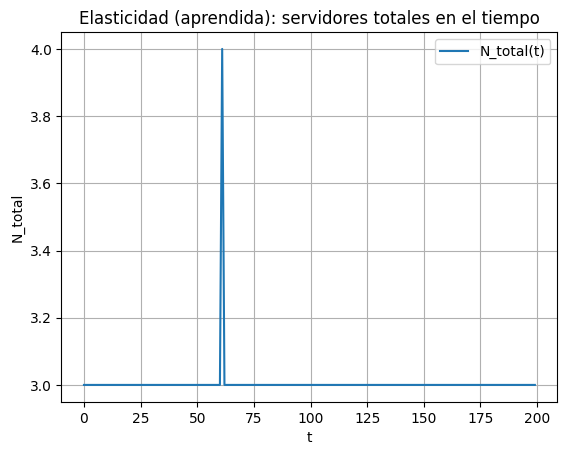

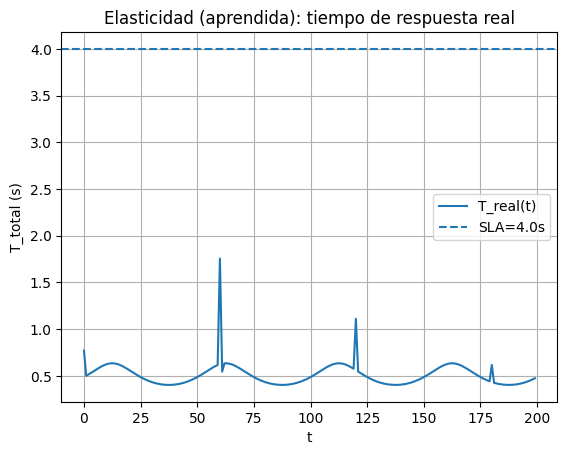

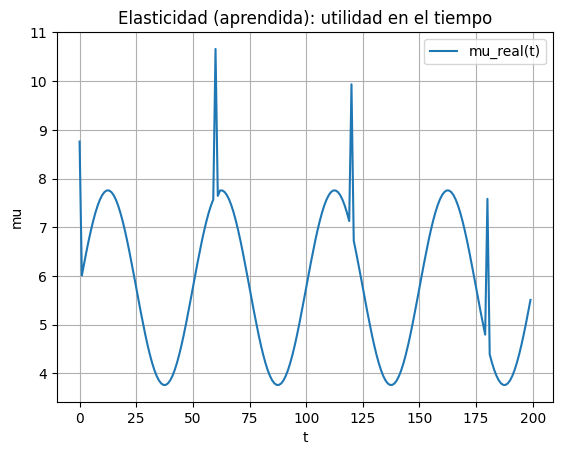

In [73]:
# λ(t)
plt.figure()
plt.plot(sim_learned["t"], sim_learned["lambda_true"], label="lambda(t)")
plt.plot(sim_learned["t"], sim_learned["lambda_hat"], label="lambda_hat(t)", linestyle="--")
plt.xlabel("t")
plt.ylabel("lambda (op/s)")
plt.title("Carga real y predicción")
plt.grid(True)
plt.legend()
plt.savefig("elasticidad_lambda.png", dpi=200, bbox_inches="tight")
plt.show()

# N_total(t)
plt.figure()
plt.plot(sim_learned["t"], sim_learned["N_total"], label="N_total(t)")
plt.xlabel("t")
plt.ylabel("N_total")
plt.title("Elasticidad (aprendida): servidores totales en el tiempo")
plt.grid(True)
plt.legend()
plt.savefig("elasticidad_Ntotal.png", dpi=200, bbox_inches="tight")
plt.show()

# T_real(t) + SLA
plt.figure()
plt.plot(sim_learned["t"], sim_learned["T_real"], label="T_real(t)")
plt.axhline(SLA, linestyle="--", label=f"SLA={SLA}s")
plt.xlabel("t")
plt.ylabel("T_total (s)")
plt.title("Elasticidad (aprendida): tiempo de respuesta real")
plt.grid(True)
plt.legend()
plt.savefig("elasticidad_Treal.png", dpi=200, bbox_inches="tight")
plt.show()

# μ(t)
plt.figure()
plt.plot(sim_learned["t"], sim_learned["mu_real"], label="mu_real(t)")
plt.xlabel("t")
plt.ylabel("mu")
plt.title("Elasticidad (aprendida): utilidad en el tiempo")
plt.grid(True)
plt.legend()
plt.savefig("elasticidad_mu.png", dpi=200, bbox_inches="tight")
plt.show()


## 11) Elasticidad ideal (benchmark) y comparación

- Elasticidad aprendida: decide N(t) usando g(N,λ).
- Elasticidad ideal: decide N(t) usando el modelo real (Seidmann) directamente.
- Comparamos utilidad media, % de violaciones de SLA, coste medio y T medio.


In [74]:
def choose_config_ideal(lam: float, Nmax_total=16):
    """
    Ideal: probamos todas las configuraciones factibles y elegimos la que maximiza utilidad
    usando el modelo real (Seidmann).
    """
    best_cfg = None
    best_mu = -1e18

    for (N_ws, N_as, N_ds) in CFG_LIST:
        # guard por capacidad U=0.9
        lam_cap, _, _ = lambda_max_theoretical_layer(fA_best, N_ws, N_as, N_ds, target_U=TARGET_U)
        if lam > lam_cap:
            continue

        _, U, _, T_real = compute_metrics_seidmann(float(lam), fA=fA_best, N_ws=N_ws, N_as=N_as, N_ds=N_ds)
        N_total = N_ws + N_as + N_ds
        mu = utility(float(lam), float(T_real), N_total)

        if mu > best_mu:
            best_mu = mu
            best_cfg = (N_ws, N_as, N_ds)

    # si no hubiese ninguna factible (raro), cae en (Nmax_total-2,1,1) o similar
    if best_cfg is None:
        best_cfg = (Nmax_total-2, 1, 1)

    return best_cfg


In [75]:
cfg_hist = []
Ntot_hist = []
T_real_hist = []
mu_real_hist = []

for k in range(T_STEPS):
    cfg = choose_config_ideal(float(lam_true[k]), Nmax_total=Nmax_total)
    N_ws, N_as, N_ds = cfg

    _, U_real, _, T_real = compute_metrics_seidmann(float(lam_true[k]), fA=fA_best, N_ws=N_ws, N_as=N_as, N_ds=N_ds)
    N_total = N_ws + N_as + N_ds
    mu = utility(float(lam_true[k]), float(T_real), N_total)

    cfg_hist.append(cfg)
    Ntot_hist.append(N_total)
    T_real_hist.append(float(T_real))
    mu_real_hist.append(float(mu))

sim_ideal = pd.DataFrame({
    "t": t,
    "lambda_true": lam_true,
    "N_ws": [c[0] for c in cfg_hist],
    "N_as": [c[1] for c in cfg_hist],
    "N_ds": [c[2] for c in cfg_hist],
    "N_total": Ntot_hist,
    "T_real": T_real_hist,
    "mu_real": mu_real_hist
})

def summary_stats(sim: pd.DataFrame, name: str):
    return pd.Series({
        "name": name,
        "mu_mean": sim["mu_real"].mean(),
        "T_mean": sim["T_real"].mean(),
        "N_total_mean": sim["N_total"].mean(),
        "SLA_violations_%": (sim["T_real"] > SLA).mean() * 100
    })

stats = pd.DataFrame([
    summary_stats(sim_learned, "learned"),
    summary_stats(sim_ideal, "ideal")
])

stats


,name,mu_mean,T_mean,N_total_mean,SLA_violations_%
0,learned,5.8196,0.513373,3.005,0.0
1,ideal,5.8196,0.508541,3.005,0.0


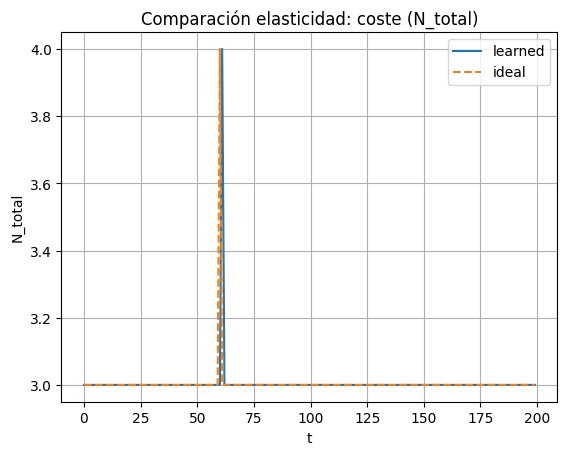

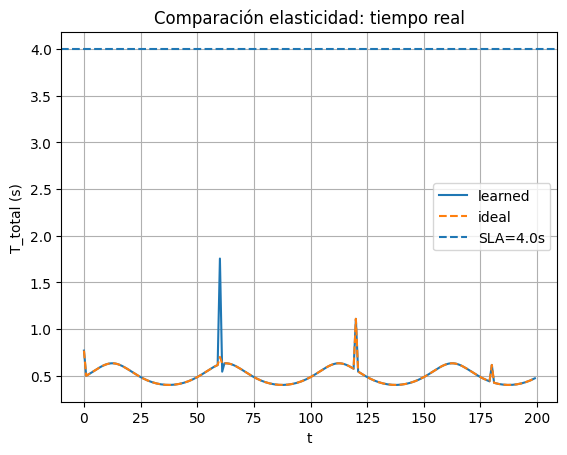

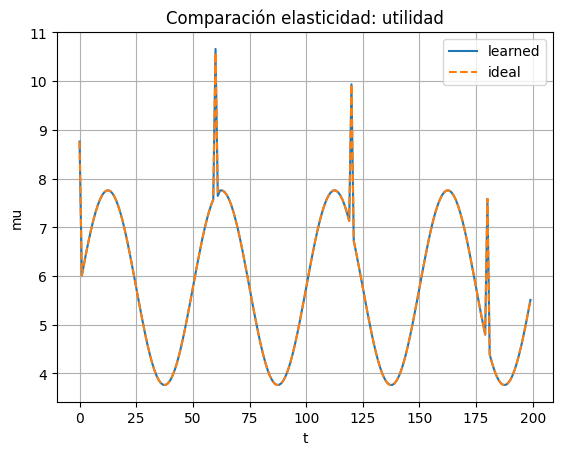

In [76]:
# Comparación N_total(t)
plt.figure()
plt.plot(sim_learned["t"], sim_learned["N_total"], label="learned")
plt.plot(sim_ideal["t"],   sim_ideal["N_total"],   label="ideal", linestyle="--")
plt.xlabel("t")
plt.ylabel("N_total")
plt.title("Comparación elasticidad: coste (N_total)")
plt.grid(True)
plt.legend()
plt.savefig("compare_Ntotal.png", dpi=200, bbox_inches="tight")
plt.show()

# Comparación T_real(t)
plt.figure()
plt.plot(sim_learned["t"], sim_learned["T_real"], label="learned")
plt.plot(sim_ideal["t"],   sim_ideal["T_real"],   label="ideal", linestyle="--")
plt.axhline(SLA, linestyle="--", label=f"SLA={SLA}s")
plt.xlabel("t")
plt.ylabel("T_total (s)")
plt.title("Comparación elasticidad: tiempo real")
plt.grid(True)
plt.legend()
plt.savefig("compare_Treal.png", dpi=200, bbox_inches="tight")
plt.show()

# Comparación μ(t)
plt.figure()
plt.plot(sim_learned["t"], sim_learned["mu_real"], label="learned")
plt.plot(sim_ideal["t"],   sim_ideal["mu_real"],   label="ideal", linestyle="--")
plt.xlabel("t")
plt.ylabel("mu")
plt.title("Comparación elasticidad: utilidad")
plt.grid(True)
plt.legend()
plt.savefig("compare_mu.png", dpi=200, bbox_inches="tight")
plt.show()
